In [1]:
from packages import *
from income_fit import *
from taxation import *

In [2]:
data_direc = '/Users/samforbes/Documents/research/income_tax/code/data/'
direc_save = '/Users/samforbes/Documents/research/income_tax/code/plots/'

# Data

Income percentiles UK:
https://www.gov.uk/government/statistics/percentile-points-from-1-to-99-for-total-income-before-and-after-tax

No. tax payers UK:
https://www.gov.uk/government/statistics/number-of-individual-income-taxpayers-by-marginal-rate-gender-and-age

UK inflation CPIH:
https://www.ons.gov.uk/economy/inflationandpriceindices/timeseries/l55o/mm23

In [3]:
data_bt = pd.read_excel(data_direc+'Table_3.1a_2223.xlsx',sheet_name = 'Table_3_1a_before_tax')
data_at = pd.read_excel(data_direc+'Table_3.1a_2223.xlsx',sheet_name = 'Table_3_1a_after_tax')

data_no = pd.read_excel(data_direc+'Table_2.1_Number_of_individual_Income_Tax_Payers.xlsx',sheet_name = '2_1_IT_payers_by_demographic')
data_CPIH = pd.read_excel(data_direc+'series-180725.xls')
data_UK_popn_16_64 = pd.read_excel(data_direc+'series-290825.xls')

In [4]:
years = np.arange(2000,2024,1).tolist()

years = list(map(str, years))

dict_bt = {years[k]: []  for k in range(len(years))} # Dictionary of UK percentile income before tax years 2000 - 2023 
dict_at = {years[k]: []  for k in range(len(years))} # Dictionary of UK percentile income after tax years 2000 - 2023 
dict_nos = {years[k]: []  for k in range(len(years))} # Dictionary of no of UK income tax payers 2000 - 2023 
dict_pop_nos = {years[k]: []  for k in range(len(years))} # Dictionary of no of UK income tax payers 2000 - 2023 excluding 2009

for i in range(len(years)):
    dict_bt[years[i]] = data_bt.values[:,i+1][4:-1]
    dict_at[years[i]] = data_at.values[:,i+1][4:-1]
    dict_nos[years[i]] = data_no.values[:,1][11+i]
    dict_pop_nos[years[i]] =data_UK_popn_16_64.values[:,1][36+i]

# Excluding 2009
del dict_bt[years[9]]
del dict_at[years[9]]
del dict_nos[years[9]]
del dict_pop_nos[years[9]]

years.remove(years[9])

for i in range(len(years)):
    dict_bt[years[i]] = np.asarray(dict_bt[years[i]],float)
    dict_at[years[i]] = np.asarray(dict_at[years[i]],float)
    dict_nos[years[i]] = np.asarray(dict_nos[years[i]],float)*1000
    dict_pop_nos[years[i]] = np.asarray(dict_pop_nos[years[i]],float)*1000

percentiles = np.arange(0.01,1,0.01)

years1 = years.copy()
years1.insert(9,'2009')

nos = list(dict_nos.values())
nos.insert(9,0)
nos = np.asarray(nos,float)

pop_nos = list(dict_pop_nos.values())
pop_nos.insert(9,1)
pop_nos = np.asarray(pop_nos,float)

In [5]:
print(len(years))

23


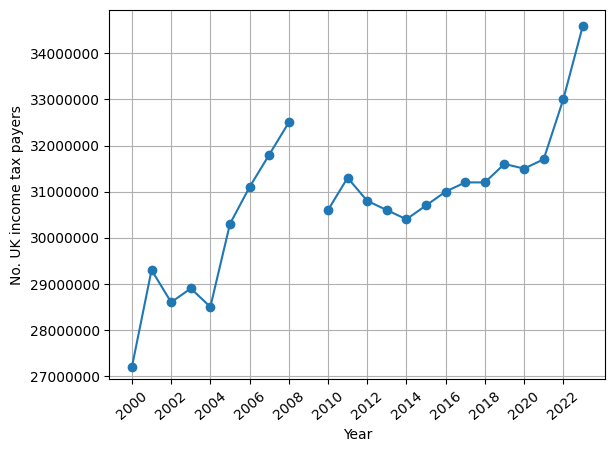

In [6]:
plt.plot(years1[:9],nos[:9],'-o',color = 'tab:blue')

plt.plot(years1[9],nos[9])

plt.plot(years1[10:],nos[10:],'-o',color = 'tab:blue')

plt.ylim((0.99*min(nos[nos>0]),1.01*max(nos)))

plt.xlabel('Year')
plt.ylabel('No. UK income tax payers')
plt.xticks(years1[::2],rotation=40)
plt.grid()

plt.ticklabel_format(axis = 'y', style = 'plain')

# plt.savefig(direc_save+'no_UK_inc_tax_payers.png', bbox_inches='tight')

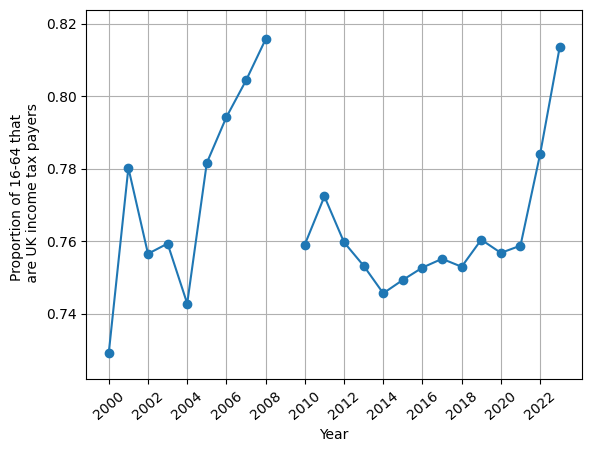

In [7]:
inc_prop = nos/pop_nos

plt.plot(years1[:9],inc_prop[:9],'-o',color = 'tab:blue')

plt.plot(years1[9],inc_prop[9])

plt.plot(years1[10:],inc_prop[10:],'-o',color = 'tab:blue')

plt.ylim((0.99*min(inc_prop[inc_prop>0]),1.01*max(inc_prop)))

plt.xlabel('Year')
plt.ylabel('Proportion of 16-64 that \n are UK income tax payers')
plt.xticks(years1[::2],rotation=40)
plt.grid()

plt.ticklabel_format(axis = 'y', style = 'plain')

In [8]:
M_bt = []
M_at = []

for i in range(len(years)):
    M_bt.append(dict_bt[years[i]])
    M_at.append(dict_at[years[i]])

M_bt = np.array(M_bt)
M_at = np.array(M_at)

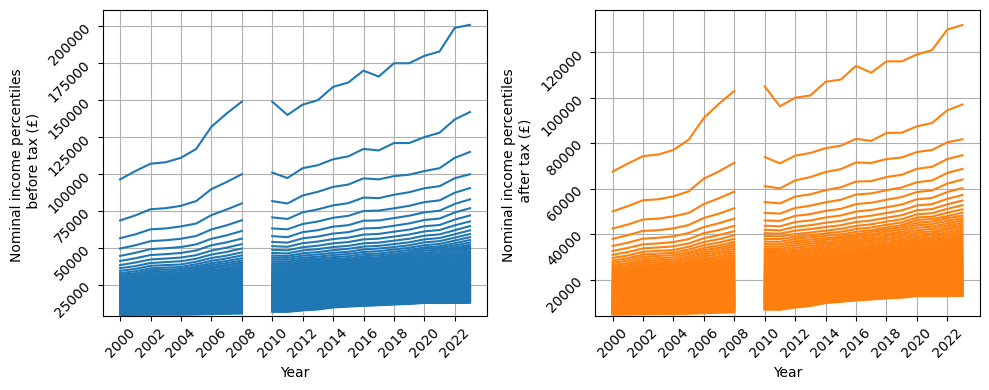

In [9]:
fig, axs = plt.subplots(1, 2,figsize=(10,4))
ax1, ax2 = axs[0], axs[1]

for i in range(99):
    M_bt_pc = list(M_bt[:,i])
    M_bt_pc.insert(9,0)

    M_at_pc = list(M_at[:,i])
    M_at_pc.insert(9,0)
    
    ax1.plot(years1[:9],M_bt_pc[:9],color = 'tab:blue')
    ax1.plot(years1[9],M_bt_pc[9])
    ax1.plot(years1[10:],M_bt_pc[10:],color = 'tab:blue')

    ax2.plot(years1[:9],M_at_pc[:9],color = 'tab:orange')
    ax2.plot(years1[9],M_at_pc[9])
    ax2.plot(years1[10:],M_at_pc[10:],color = 'tab:orange')


for ax in axs:
    ax.set_ylim(4000)
    ax.set_xticks(years1[::2]) 
    ax.tick_params(labelrotation=45)
    ax.set_xlabel('Year')
    ax.grid()
    # ax.set_yscale("log")
    
ax1.set_ylabel('Nominal income percentiles \n before tax (£)')
ax2.set_ylabel('Nominal income percentiles \n after tax (£)')

fig.tight_layout()

# plt.savefig(direc_save+'nominal_income_percentiles.png', bbox_inches='tight')

In [10]:
income_growth_bt = []
income_growth_at = []

k1, k2 = 0, -1

for i in range(99):
    income_growth_bt.append(M_bt[:,i][k2]/M_bt[:,i][k1])
    income_growth_at.append(M_at[:,i][k2]/M_at[:,i][k1])

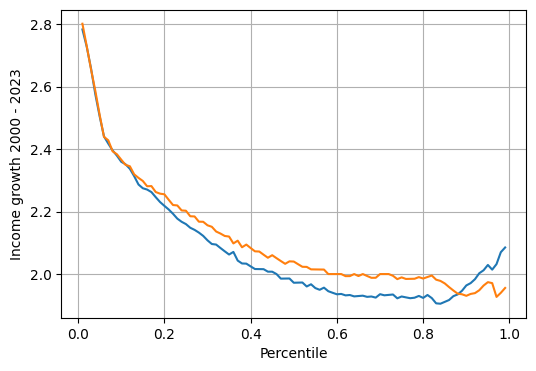

In [11]:
fig, ax = plt.subplots(1, 1,figsize=(6,4))
ax.plot(percentiles,income_growth_bt)
ax.plot(percentiles,income_growth_at)
ax.set_xlabel('Percentile')
ax.set_ylabel(f'Income growth {years[k1]} - {years[k2]}')
ax.grid()
# ax.axhline(1,color='black',linestyle='--')

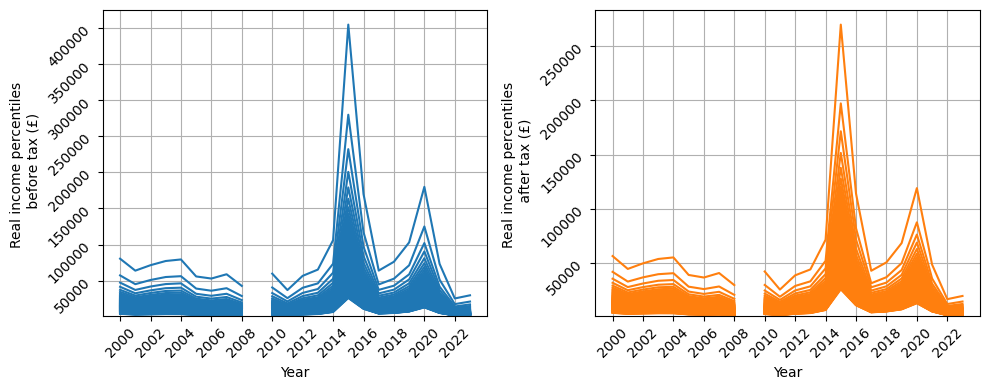

In [12]:
fig, axs = plt.subplots(1, 2,figsize=(10,4))
ax1, ax2 = axs[0], axs[1]

for i in range(99):
    M_bt_pc = list(M_bt[:,i])
    M_bt_pc.insert(9,0)
    M_bt_pc = np.array(M_bt_pc)/data_CPIH.values[:,1][18:42]

    M_at_pc = list(M_at[:,i])
    M_at_pc.insert(9,0)
    M_at_pc = np.array(M_at_pc)/data_CPIH.values[:,1][18:42]
    
    ax1.plot(years1[:9],M_bt_pc[:9],color = 'tab:blue')
    ax1.plot(years1[9],M_bt_pc[9])
    ax1.plot(years1[10:],M_bt_pc[10:],color = 'tab:blue')

    ax2.plot(years1[:9],M_at_pc[:9],color = 'tab:orange')
    ax2.plot(years1[9],M_at_pc[9])
    ax2.plot(years1[10:],M_at_pc[10:],color = 'tab:orange')


for ax in axs:
    ax.set_ylim(1000)
    ax.set_xticks(years1[::2]) 
    ax.tick_params(labelrotation=45)
    ax.set_xlabel('Year')
    ax.grid()
    # ax.set_yscale("log")
    
ax1.set_ylabel('Real income percentiles \n before tax (£)')
ax2.set_ylabel('Real income percentiles \n after tax (£)')


fig.tight_layout()

# plt.savefig(direc_save+'real_income_percentiles.png', bbox_inches='tight')

## Income Distribution Before and After Tax

0.003166158101852345 [1.26982984e+00 8.20939584e-01 1.79795159e+00 1.02496863e-08]
0.0024253869263712543 [1.33911541e+00 6.76730183e-01 1.83883494e+00 8.33790331e-09]
CPU times: user 2.77 s, sys: 10.8 ms, total: 2.78 s
Wall time: 2.78 s


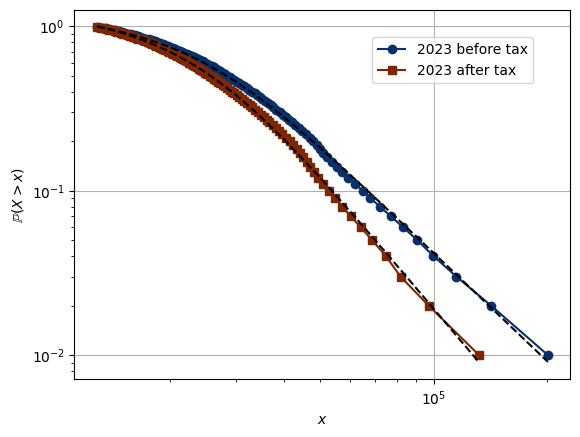

In [13]:
%%time
n = len(years)
cmap = plt.get_cmap("Blues")
colors = [cmap(i) for i in np.linspace(0.3, 1, n)]

cmap1 = plt.get_cmap("Oranges")
colors1 = [cmap1(i) for i in np.linspace(0.3, 1, n)]

i = -1
x1 = dict_bt[years[i]]
x2 = dict_at[years[i]]

y = percentiles[::-1]
g_b, g_a = 1.3, 1.3

u1, u2 = 0, None
error_min1, popt1 = param_fit(x1[u1:u2],y[u1:u2],g_b)
error_min2, popt2 = param_fit(x2[u1:u2],y[u1:u2],g_a)

print(error_min1,popt1)
print(error_min2,popt2)

k1, k2 = 0, None
plt.loglog(x1[k1:k2],y[k1:k2],'-o', label = years[i]+' before tax', color = colors[i])
plt.loglog(x2[k1:k2],y[k1:k2],'-s', label = years[i]+' after tax', color = colors1[i])

plt.loglog(x1[k1:k2],k_gen_tail(x1,*popt1)[k1:k2],color='black',linestyle = '--')
plt.loglog(x2[k1:k2],k_gen_tail(x2,*popt2)[k1:k2],color='black',linestyle = '--')

plt.xlabel(r'$x$')
plt.ylabel(r'$\mathbb{P}(X>x)$')
plt.legend(loc = (0.6,0.8),fontsize = 10)
plt.grid()

# plt.savefig(direc_save+f'income_dist_{years[i]}.png', bbox_inches='tight')

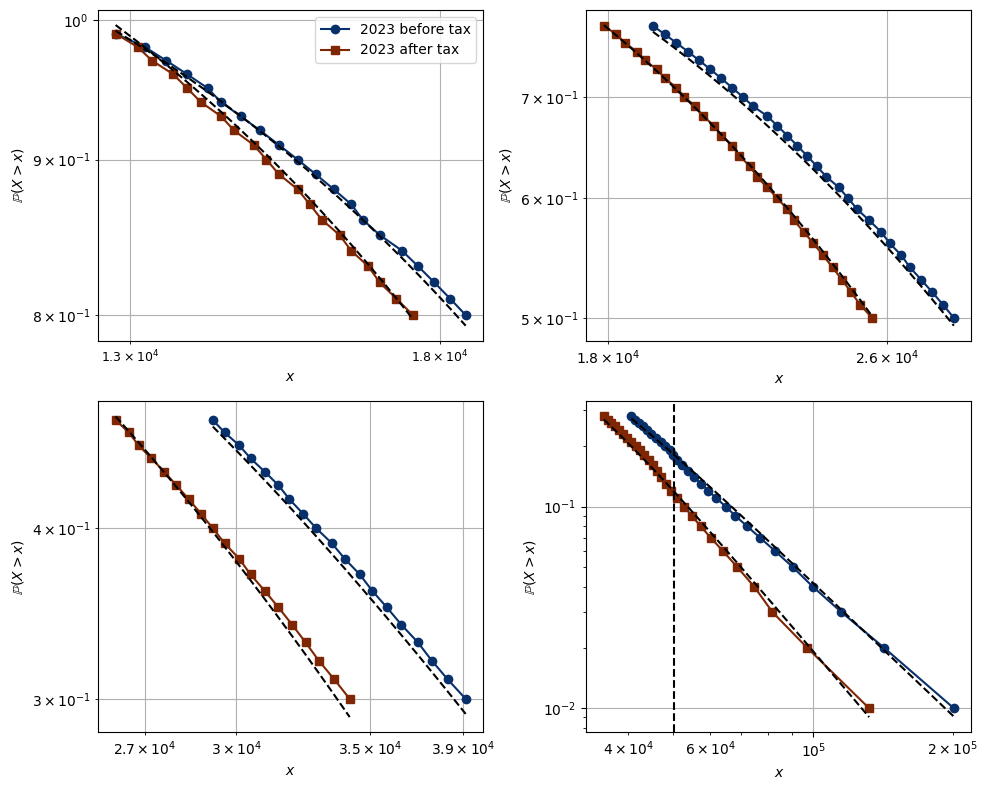

In [14]:
import matplotlib.ticker as ticker
from matplotlib.ticker import FixedLocator

fig, axs = plt.subplots(2, 2,figsize=(10,8))

k1, k2 = 0, 20

axs[0,0].loglog(x1[k1:k2],y[k1:k2],'-o', label = years[i]+' before tax', color = colors[i])
axs[0,0].loglog(x2[k1:k2],y[k1:k2],'-s', label = years[i]+' after tax', color = colors1[i])

axs[0,0].loglog(x1[k1:k2],k_gen_tail(x1,*popt1)[k1:k2],color='black',linestyle = '--')
axs[0,0].loglog(x2[k1:k2],k_gen_tail(x2,*popt2)[k1:k2],color='black',linestyle = '--')

axs[0,0].tick_params(axis='x', which='minor', labelsize=9)

axs[0,0].xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=[1.3,1.8], numticks=20))
axs[0,0].grid(True, which="both")

axs[0,0].legend()

k1, k2 = 21, 50

axs[0,1].loglog(x1[k1:k2],y[k1:k2],'-o', label = years[i]+' before tax', color = colors[i])
axs[0,1].loglog(x2[k1:k2],y[k1:k2],'-s', label = years[i]+' after tax', color = colors1[i])

axs[0,1].loglog(x1[k1:k2],k_gen_tail(x1,*popt1)[k1:k2],color='black',linestyle = '--')
axs[0,1].loglog(x2[k1:k2],k_gen_tail(x2,*popt2)[k1:k2],color='black',linestyle = '--')

axs[0,1].xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=[1.8,2.6], numticks=20))
axs[0,1].grid(True, which="both")

k1, k2 = 51, 70

axs[1,0].loglog(x1[k1:k2],y[k1:k2],'-o', label = years[i]+' before tax', color = colors[i])
axs[1,0].loglog(x2[k1:k2],y[k1:k2],'-s', label = years[i]+' after tax', color = colors1[i])

axs[1,0].loglog(x1[k1:k2],k_gen_tail(x1,*popt1)[k1:k2],color='black',linestyle = '--')
axs[1,0].loglog(x2[k1:k2],k_gen_tail(x2,*popt2)[k1:k2],color='black',linestyle = '--')

# axs[1,0].xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=[2.5,3.9], numticks=10))
axs[1,0].xaxis.set_minor_locator(
    FixedLocator([2.7e4, 3e4, 3.5e4, 3.9e4])  # explicitly choose ticks
)
axs[1,0].grid(True, which="both")

k1, k2 = 71, None

axs[1,1].loglog(x1[k1:k2],y[k1:k2],'-o', label = years[i]+' before tax', color = colors[i])
axs[1,1].loglog(x2[k1:k2],y[k1:k2],'-s', label = years[i]+' after tax', color = colors1[i])

axs[1,1].loglog(x1[k1:k2],k_gen_tail(x1,*popt1)[k1:k2],color='black',linestyle = '--')
axs[1,1].loglog(x2[k1:k2],k_gen_tail(x2,*popt2)[k1:k2],color='black',linestyle = '--')

axs[1,1].axvline(x=50270, color='black', linestyle='--') # Distortion due to tax bracket?

axs[1,1].grid()

for ax in axs.ravel():   
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$\mathbb{P}(X>x)$')

fig.tight_layout()

# plt.savefig(direc_save+f'income_dist_break_down_{years[i]}.png', bbox_inches='tight')

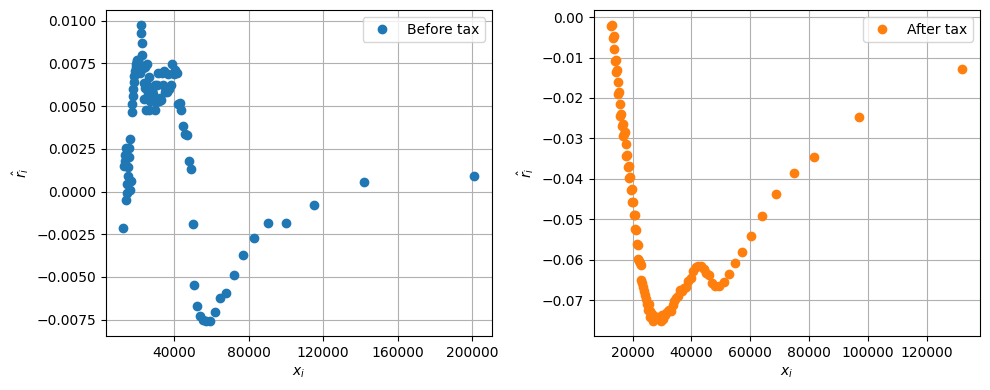

In [15]:
from matplotlib.ticker import MaxNLocator
# Residuals
n = np.arange(1,100,1)

resid1 = y[u1:u2] - k_gen_tail(x1,*popt1)[u1:u2]
resid2 = y[u1:u2] - k_gen_tail(x2,*popt1)[u1:u2]

fig, axs = plt.subplots(1, 2,figsize=(10,4))
ax1, ax2 = axs[0], axs[1]

ax1.plot(x1, resid1, 'o', color = 'tab:blue', label = 'Before tax')
ax2.plot(x2, resid2, 'o', color = 'tab:orange', label = 'After tax')

ax1.xaxis.set_major_locator(MaxNLocator(nbins=6))

for ax in axs.ravel():   
    ax.set_xlabel(r'$x_i$')
    ax.set_ylabel(r'$\hat{r_i}$')
    ax.grid()
    ax.legend()

fig.tight_layout()

# plt.savefig(direc_save+f'residuals_{years[i]}.png', bbox_inches='tight')

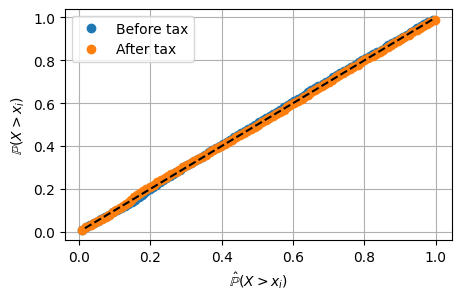

In [16]:
# QQ plot
fig, ax = plt.subplots(figsize=(5,3))

ax.plot(k_gen_tail(x1,*popt1)[u1:u2],y[u1:u2],'o', label = 'Before tax')
ax.plot(k_gen_tail(x2,*popt2)[u1:u2],y[u1:u2],'o', label = 'After tax')
ax.plot(y[u1:u2],y[u1:u2],color = 'black', linestyle = '--')

ax.set_xlabel(r'$\hat{\mathbb{P}}(X>x_i)$')
ax.set_ylabel(r'$\mathbb{P}(X>x_i)$')
ax.grid()
ax.legend()

In [17]:
dict_params_bt = {years[k]: []  for k in range(len(years))} # Dictionary of income parameter fit before tax
dict_params_at = {years[k]: []  for k in range(len(years))} # Dictionary of income parameter fit after tax

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22


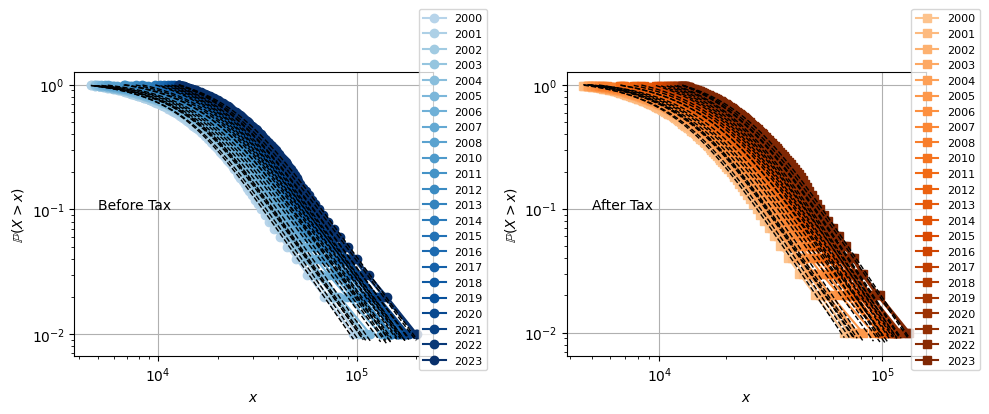

In [18]:
fig, axs = plt.subplots(1, 2,figsize=(10,4))
n = len(years)
ax1, ax2 = axs[0], axs[1]

cmap = plt.get_cmap("Blues")
colors = [cmap(i) for i in np.linspace(0.3, 1, n)]

cmap1 = plt.get_cmap("Oranges")
colors1 = [cmap1(i) for i in np.linspace(0.3, 1, n)]

for i in range(n):
    x1, x2 = dict_bt[years[i]],dict_at[years[i]]
    y = percentiles[::-1]
    ax1.loglog(x1,y,'-o', label = years[i], color = colors[i])
    ax2.loglog(x2,y,'-s', label = years[i], color = colors1[i])
    # ax1.legend(fontsize = 8)

for i in range(n):
    print(i)
    x1, x2 = dict_bt[years[i]],dict_at[years[i]]
    y = percentiles[::-1]
    g_b, g_a = 1.3, 1.3
    error_min1, popt1 = param_fit(x1,y,g_b)
    error_min2, popt2 = param_fit(x2,y,g_a)
    dict_params_bt[years[i]] = popt1
    dict_params_at[years[i]] = popt2
    ax1.loglog(x1,k_gen_tail(x1,*popt1),color = 'black',linewidth=1,linestyle='--')
    ax2.loglog(x2,k_gen_tail(x2,*popt2),color = 'black',linewidth=1,linestyle='--')

ax1.legend(loc=(0.96, -0.05),fontsize = 8)
ax2.legend(loc=(0.96, -0.05),fontsize = 8)

ax1.grid()
ax2.grid()

ax1.text(0.5*10**4,10**-1,'Before Tax')
ax2.text(0.5*10**4,10**-1,'After Tax')

ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$\mathbb{P}(X>x)$')

ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$\mathbb{P}(X>x)$')

fig.tight_layout()

# plt.savefig(direc_save+'income_dist_fits.png', bbox_inches='tight')

In [19]:
dict_x_m_bt = {years[k]: []  for k in range(len(years))} # Dictionary of x_ms before tax
dict_x_m_at = {years[k]: []  for k in range(len(years))} # Dictionary of x_ms after tax

In [20]:
for i in range(len(years)):
    x_m_bt = get_x_m(*dict_params_bt[years[i]])
    x_m_at = get_x_m(*dict_params_at[years[i]])
    dict_x_m_bt[years[i]] = x_m_bt
    dict_x_m_at[years[i]] = x_m_at

In [21]:
latex = r"\frac{a}{b} + \sqrt{x^2 + y^2}"
print(latex)

\frac{a}{b} + \sqrt{x^2 + y^2}


In [22]:
print(f"{'$x_m$ before tax':>18}")
print(f"{'Year':<6} {'$x_m$':>15}")
print("-" * 25)
for year, value in dict_x_m_bt.items():
    print(f"{year:<6} {value:>15.2f}")

print('')
print(f"{'$x_m$ after tax':>18}")
print(f"{'Year':<6} {'$x_m$':>15}")
print("-" * 25)
for year, value in dict_x_m_at.items():
    print(f"{year:<6} {value:>15.2f}")

  $x_m$ before tax
Year             $x_m$
-------------------------
2000           4307.28
2001           4252.75
2002           4270.25
2003           4424.71
2004           4067.31
2005           4321.59
2006           4861.44
2007           4653.70
2008           5364.07
2010           6875.29
2011           6625.33
2012           7611.02
2013           8255.32
2014           9661.04
2015           9911.90
2016          10561.20
2017          11033.64
2018          11576.99
2019          11908.24
2020          12638.16
2021          12595.25
2022          12790.21
2023          12567.56

   $x_m$ after tax
Year             $x_m$
-------------------------
2000           4763.26
2001           4598.62
2002           4912.92
2003           4989.90
2004           5007.23
2005           5059.16
2006           5152.95
2007           5446.23
2008           5357.88
2010           6680.02
2011           6763.40
2012           7629.01
2013           8385.76
2014           9546.98
2015        

In [23]:
# Create DataFrame
df1 = pd.DataFrame(dict_params_bt, index=["A", "kappa", "alpha", "beta"]).T
df2 = pd.DataFrame(dict_params_at, index=["A", "kappa", "alpha", "beta"]).T

# Display table
print('Distribution parameter fits before tax \n')
print(df1)
print(' \n Distribution parameter fits after tax \n')
print(df2)

Distribution parameter fits before tax 

             A     kappa     alpha          beta
2000  1.092349  0.811354  1.874285  1.364433e-08
2001  1.096090  0.785153  1.796106  2.789342e-08
2002  1.076620  0.824269  1.871927  1.181786e-08
2003  1.090347  0.773199  1.789978  2.577898e-08
2004  1.065033  0.816245  1.868047  1.140808e-08
2005  1.078219  0.785465  1.790591  2.328926e-08
2006  1.093088  0.824621  1.788664  2.266873e-08
2007  1.072756  0.863421  1.843844  1.213240e-08
2008  1.099312  0.845105  1.785471  2.078928e-08
2010  1.150403  0.819729  1.782374  2.032090e-08
2011  1.151248  0.757725  1.713369  4.003431e-08
2012  1.185002  0.782626  1.729081  3.309354e-08
2013  1.209201  0.780916  1.730550  3.177977e-08
2014  1.305701  0.779336  1.692395  4.841466e-08
2015  1.277414  0.820253  1.776494  1.961754e-08
2016  1.304620  0.829196  1.774180  1.947417e-08
2017  1.328720  0.806482  1.763967  2.119449e-08
2018  1.331993  0.823247  1.792800  1.500386e-08
2019  1.337498  0.807340  1.

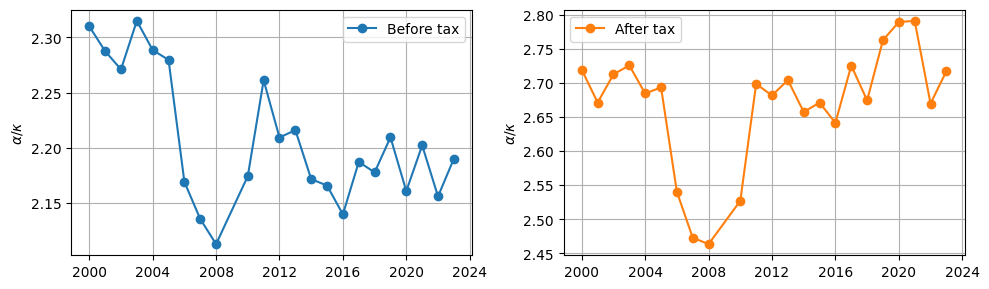

In [24]:
fig, axs = plt.subplots(1, 2,figsize=(10,3))

ax1, ax2 = axs[0], axs[1]

years_dt = [datetime.strptime(year, '%Y').date() for year in years]

ax1.plot(years_dt,df1.alpha.values/df1.kappa.values,'-o', label = 'Before tax',color = 'tab:Blue')
ax2.plot(years_dt,df2.alpha.values/df2.kappa.values,'-o', label = 'After tax',color = 'tab:Orange')

ax1.grid()
ax2.grid()

ax1.legend()
ax2.legend()

ax1.set_ylabel(r'$\alpha/\kappa$')

ax2.set_ylabel(r'$\alpha/\kappa$')

fig.tight_layout()

# plt.savefig(direc_save+'power_law_coef.png', bbox_inches='tight')

In [25]:
dict_gen_pop_bt = {years[k]: []  for k in range(len(years))} # Dictionary of generated income population before tax
dict_gen_pop_at = {years[k]: []  for k in range(len(years))} # Dictionary of generated income population after tax

In [26]:
%%time
for i in range(len(years)):
    x1 = dict_bt[years[i]]
    x2 = dict_at[years[i]]
    
    n = int(dict_nos[years[i]])

    s_bt = gen_k_gen_sample(n,*dict_params_bt[years[i]])
    s_at = gen_k_gen_sample(n,*dict_params_at[years[i]])

    dict_gen_pop_bt[years[i]] = s_bt
    dict_gen_pop_at[years[i]] = s_at

    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
CPU times: user 4min 34s, sys: 19.2 s, total: 4min 53s
Wall time: 5min 1s


In [27]:
total_income_bt = []
total_income_at = []

for i in range(len(years)):
    n_bt = len(np.where(dict_gen_pop_bt[years[i]]>10**7)[0])
    n_at = len(np.where(dict_gen_pop_at[years[i]]>10**7)[0])
    M_bt, M_at = max(dict_gen_pop_bt[years[i]]), max(dict_gen_pop_at[years[i]])
    total_income_bt.append(np.sum(dict_gen_pop_bt[years[i]]))
    total_income_at.append(np.sum(dict_gen_pop_at[years[i]]))
    print(years[i],n_bt,n_at,M_bt, M_at)

2000 11 1 21809368.91745415 50776475.44321175
2001 4 0 18805001.4843987 9275608.23101223
2002 12 1 50504942.24111765 10830741.632948568
2003 2 0 36322483.067838885 6923331.296479654
2004 10 1 75372934.0415176 13410941.826467842
2005 11 0 66407591.05635935 6644655.148641134
2006 24 1 51776899.420751184 10237492.105518425
2007 16 2 168471476.03961304 15806592.07557617
2008 42 5 70208339.6207067 60908852.58732218
2010 18 8 39839930.64647483 43679359.276092365
2011 11 1 59468146.63618182 13648404.00055593
2012 17 0 26673943.95370757 7845560.093298229
2013 35 2 53112051.16228338 25772754.33693983
2014 41 1 111735935.63582785 11304055.503944952
2015 40 2 99968215.68987377 11215810.407478627
2016 38 2 48477835.7539279 15012849.458030084
2017 45 1 106613977.06669725 19974874.759338733
2018 38 2 37887412.69249288 13649602.198132172
2019 38 3 75293684.37270807 16568274.557195066
2020 45 1 94339379.28236079 12891738.728983205
2021 41 1 57801095.5970449 12831608.947936783
2022 73 3 102679463.51798

In [28]:
years_dt = [datetime.strptime(year, '%Y').date() for year in years]

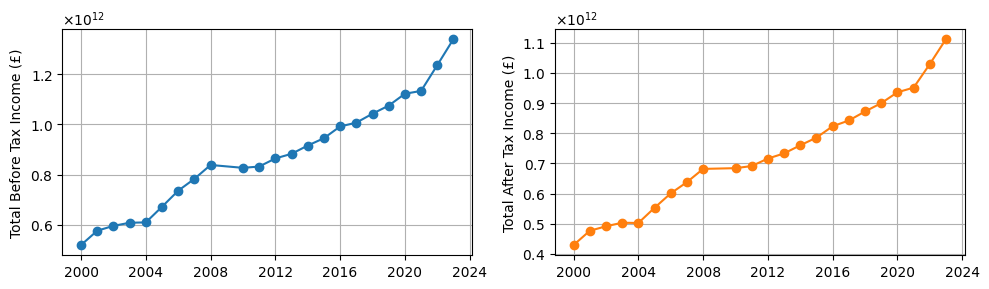

In [29]:
# Total income from samples

from matplotlib.ticker import ScalarFormatter

fig, axs = plt.subplots(1, 2,figsize=(10,3))

ax1, ax2 = axs[0], axs[1]

ax1.plot(years_dt,total_income_bt,'-o',color = 'tab:blue')
ax2.plot(years_dt,total_income_at,'-o',color = 'tab:orange')

# Use math text for scientific notation
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))  # force scientific notation if outside this range
ax1.yaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

ax1.grid()
ax2.grid()

ax1.set_ylabel('Total Before Tax Income (£)')
ax2.set_ylabel('Total After Tax Income (£)')

fig.tight_layout()

# plt.savefig(direc_save+'total_income.png', bbox_inches='tight')

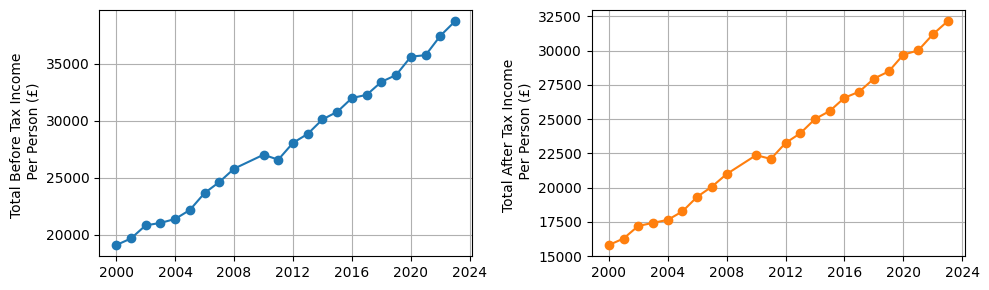

In [30]:
# Income per worker from samples

fig, axs = plt.subplots(1, 2,figsize=(10,3))

ax1, ax2 = axs[0], axs[1]

nos1 = np.asarray(list(dict_nos.values()),float)

ax1.plot(years_dt,total_income_bt/nos1,'-o',color = 'tab:blue')
ax2.plot(years_dt,total_income_at/nos1,'-o',color = 'tab:orange')

ax1.grid()
ax2.grid()

ax1.set_ylabel('Total Before Tax Income \n Per Person (£)')
ax2.set_ylabel('Total After Tax Income \n Per Person (£)')

fig.tight_layout()

In [31]:
%%time
i = -1

x_emp_bt, y_emp_bt = emp_tail(dict_gen_pop_bt[years[i]])
x_emp_at, y_emp_at = emp_tail(dict_gen_pop_at[years[i]])

CPU times: user 1.42 s, sys: 333 ms, total: 1.75 s
Wall time: 1.83 s


CPU times: user 1.17 s, sys: 1.68 s, total: 2.85 s
Wall time: 3.6 s


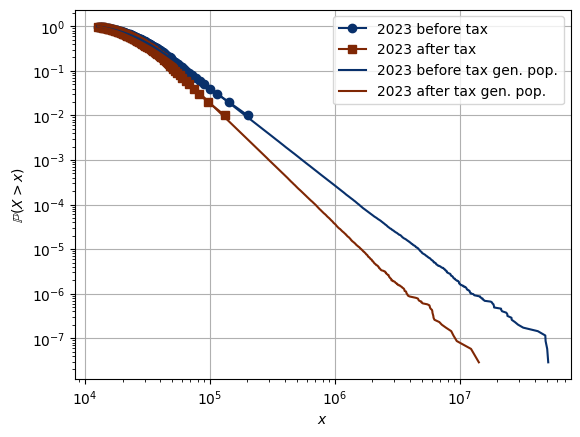

In [32]:
%%time
plt.loglog(dict_bt[years[i]],y,'-o', label = years[i]+' before tax', color = colors[i])
plt.loglog(dict_at[years[i]],y,'-s', label = years[i]+' after tax', color = colors1[i])

if len(x_emp_bt) == len(y_emp_bt):
    plt.loglog(x_emp_bt, y_emp_bt, label = years[i]+' before tax gen. pop.', color = colors[i])
else:
    plt.loglog(x_emp_bt, y_emp_bt[:-1],label = years[i]+' before tax gen. pop.', color = colors[i])

if len(x_emp_at) == len(y_emp_at):
    plt.loglog(x_emp_at, y_emp_at, label = years[i]+' after tax gen. pop.', color = colors1[i])
else:
    plt.loglog(x_emp_at, y_emp_at[:-1], label = years[i]+' after gen. pop.', color = colors1[i])

plt.xlabel(r'$x$')
plt.ylabel(r'$\mathbb{P}(X>x)$')
plt.legend(fontsize = 10)
plt.grid()

CPU times: user 2min 6s, sys: 18.8 s, total: 2min 25s
Wall time: 2min 36s


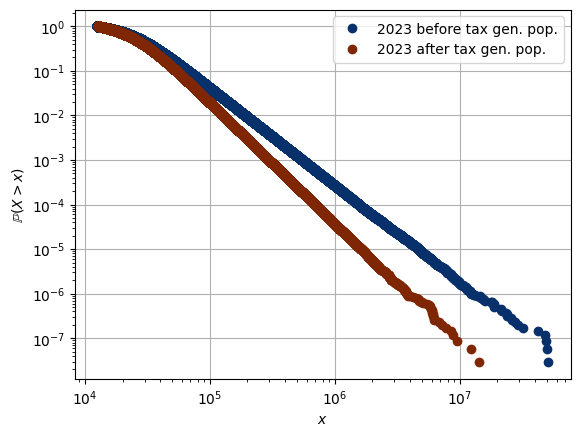

In [33]:
%%time
if len(x_emp_bt) == len(y_emp_bt):
    plt.loglog(x_emp_bt, y_emp_bt, 'o',label = years[i]+' before tax gen. pop.', color = colors[i])
else:
    plt.loglog(x_emp_bt, y_emp_bt[:-1], 'o',label = years[i]+' before tax gen. pop.', color = colors[i])

if len(x_emp_at) == len(y_emp_at):
    plt.loglog(x_emp_at, y_emp_at, 'o', label = years[i]+' after tax gen. pop.', color = colors1[i])
else:
    plt.loglog(x_emp_at, y_emp_at[:-1], 'o', label = years[i]+' after gen. pop.', color = colors1[i])

plt.xlabel(r'$x$')
plt.ylabel(r'$\mathbb{P}(X>x)$')
plt.legend(fontsize = 10)
plt.grid()

plt.savefig(direc_save+f'income_dist_pop_{years[i]}.png', bbox_inches='tight')

## Income Inequality

In [34]:
%%time
n = len(years)

ginib = []
ginia = []

Theilb = []
Theila = []

for i in range(n):

    s_bt = dict_gen_pop_bt[years[i]]
    s_at = dict_gen_pop_at[years[i]]

    gb = gini(s_bt)
    ga = gini(s_at)

    Tb = Theil(s_bt)
    Ta = Theil(s_at)
    
    ginib.append(gb)
    ginia.append(ga)

    Theilb.append(Tb)
    Theila.append(Ta)

    print(years[i])


2000
2001
2002
2003
2004
2005
2006
2007
2008
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
CPU times: user 42.2 s, sys: 25.8 s, total: 1min 7s
Wall time: 2min 25s


In [35]:
years_dt = [datetime.strptime(year, '%Y').date() for year in years]

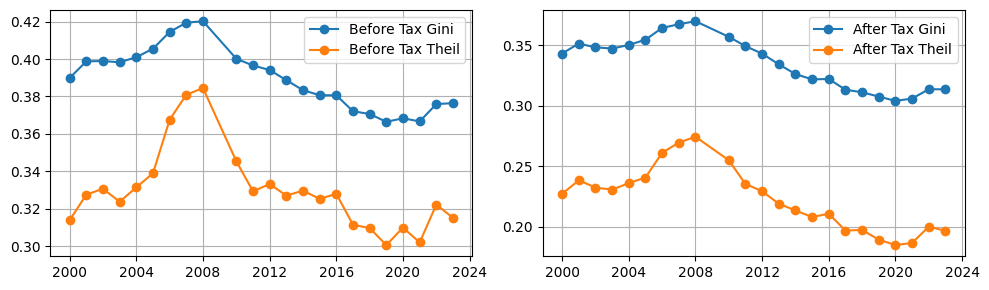

In [36]:
fig, axs = plt.subplots(1, 2,figsize=(10,3))
axs[0].plot(years_dt, ginib,'-o',label='Before Tax Gini')
axs[1].plot(years_dt,ginia,'-o',label='After Tax Gini')
axs[0].plot(years_dt,Theilb,'-o',label='Before Tax Theil')
axs[1].plot(years_dt,Theila,'-o',label='After Tax Theil')

axs[0].legend()
axs[1].legend()
axs[0].grid()
axs[1].grid()
fig.tight_layout()

# plt.savefig(direc_save+'Gini_Theil.png', bbox_inches='tight')

In [37]:
%%time
n = len(years)

p = np.arange(0.1,1,0.1) # deciles
print(p)

srs_bt = []
srs_at = []

for i in range(n):

    s_bt = dict_gen_pop_bt[years[i]]
    s_at = dict_gen_pop_at[years[i]]
    
    sr_bt = share_ratios(s_bt,p)
    sr_at = share_ratios(s_at,p)
    
    srs_bt.append(sr_bt)
    srs_at.append(sr_at)

    print(years[i])

srs_bt = np.array(srs_bt)
srs_at = np.array(srs_at)

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
2000
2001
2002
2003
2004
2005
2006
2007
2008
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
CPU times: user 31.8 s, sys: 12.6 s, total: 44.4 s
Wall time: 17min 20s


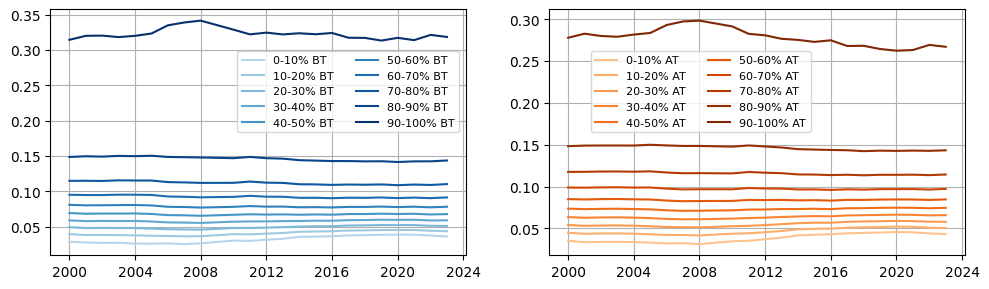

In [38]:
labels = ['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100']
n = len(labels)

cmap = plt.get_cmap("Blues")
colors = [cmap(i) for i in np.linspace(0.3, 1, n)]

cmap1 = plt.get_cmap("Oranges")
colors1 = [cmap1(i) for i in np.linspace(0.3, 1, n)]

fig, axs = plt.subplots(1, 2,figsize=(10,3))

ax1, ax2 = axs[0], axs[1]

for i in range(n):
    ax1.plot(years_dt,srs_bt[:,i],'-',label = labels[i]+'% BT', color = colors[i])
    ax2.plot(years_dt,srs_at[:,i],'-',label = labels[i]+'% AT', color = colors1[i])
    ax1.legend(loc = (0.45,0.5),ncol=2,fontsize = 8)
    ax2.legend(loc = (0.1,0.5),ncol=2,fontsize = 8)

ax1.grid()
ax2.grid()

fig.tight_layout()

# plt.savefig(direc_save+'income_decile_shares.png', bbox_inches='tight')

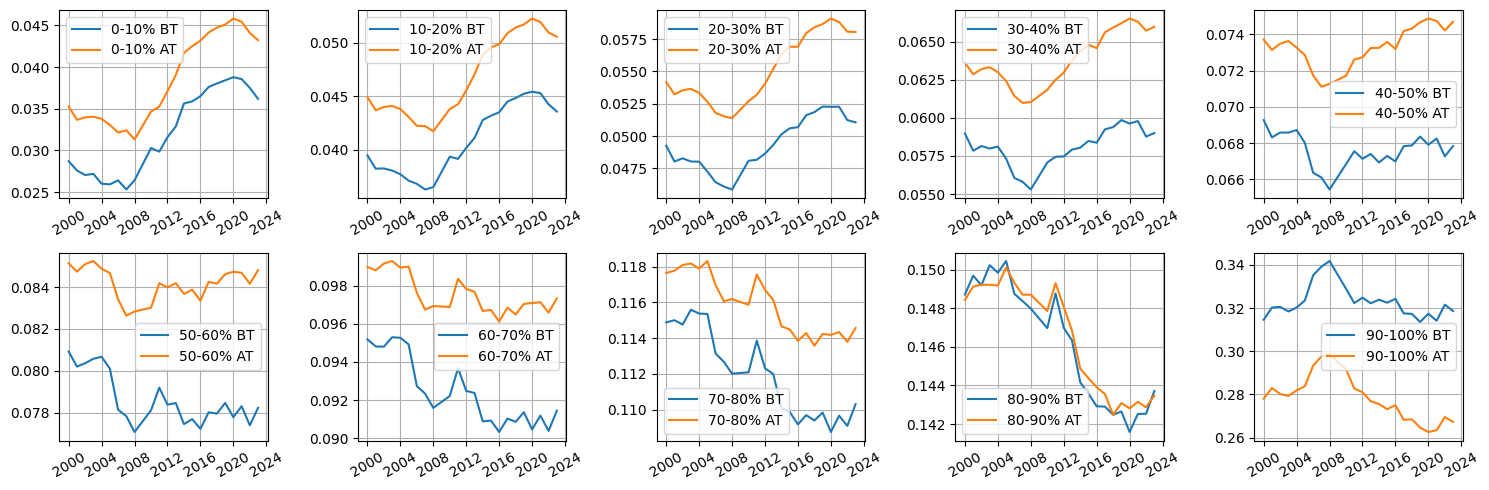

In [39]:
labels = ['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100']
n = len(labels)

fig, axs = plt.subplots(2, 5,figsize=(15,5))

axs = axs.ravel()

for i in range(n):
    ax = axs[i]
    ax.tick_params(axis='x', labelrotation=30)
    ax.plot(years_dt,srs_bt[:,i],label = labels[i]+'% BT')
    ax.plot(years_dt,srs_at[:,i],label = labels[i]+'% AT')
    ax.grid()
    ax.legend()
        

fig.tight_layout()

# plt.savefig(direc_save+'income_decile_shares1.png', bbox_inches='tight')

In [40]:
%%time
n = len(years)
xs = [0.05,10**-2,10**-3,10**-4]
s_bt_xs = []
s_at_xs = []

for i in range(n):
    
    s_bt = dict_gen_pop_bt[years[i]]
    s_at = dict_gen_pop_at[years[i]]
    s_bt_xs_i = []
    s_at_xs_i = []
    
    for x in xs:
        s_bt_xs_i.append(top_x_share(s_bt,x))
        s_at_xs_i.append(top_x_share(s_at,x))
        
    s_bt_xs.append(s_bt_xs_i)  
    s_at_xs.append(s_at_xs_i)  
    
    print(years[i])

s_bt_xs = np.array(s_bt_xs)
s_at_xs = np.array(s_at_xs)

2000
2001
2002
2003
2004
2005
2006
2007
2008
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
CPU times: user 1min 50s, sys: 17.9 s, total: 2min 8s
Wall time: 3min 17s


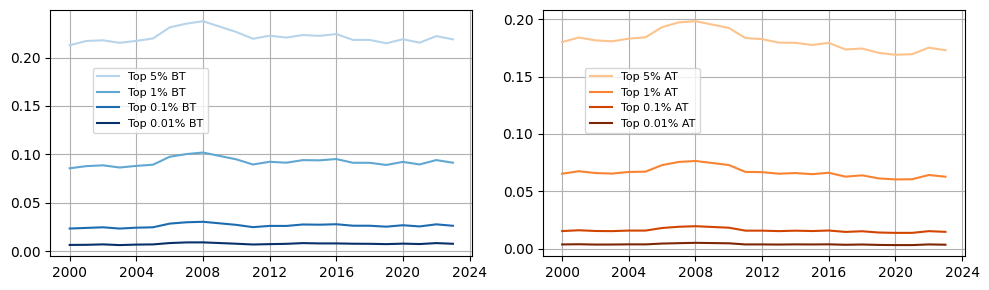

In [41]:
labels = ['Top 5%','Top 1%','Top 0.1%','Top 0.01%']
n = len(labels)

cmap = plt.get_cmap("Blues")
colors = [cmap(i) for i in np.linspace(0.3, 1, n)]

cmap1 = plt.get_cmap("Oranges")
colors1 = [cmap1(i) for i in np.linspace(0.3, 1, n)]

fig, axs = plt.subplots(1, 2,figsize=(10,3))

ax1, ax2 = axs[0], axs[1]

for i in range(n):
    ax1.plot(years_dt,s_bt_xs[:,i],label = labels[i]+' BT', color = colors[i])
    ax2.plot(years_dt,s_at_xs[:,i],label = labels[i]+' AT', color = colors1[i])
    ax1.legend(loc = (0.1,0.5),fontsize = 8)
    ax2.legend(loc = (0.1,0.5),fontsize = 8)

ax1.grid()
ax2.grid()

fig.tight_layout()

# plt.savefig(direc_save+'income_top_shares.png', bbox_inches='tight')

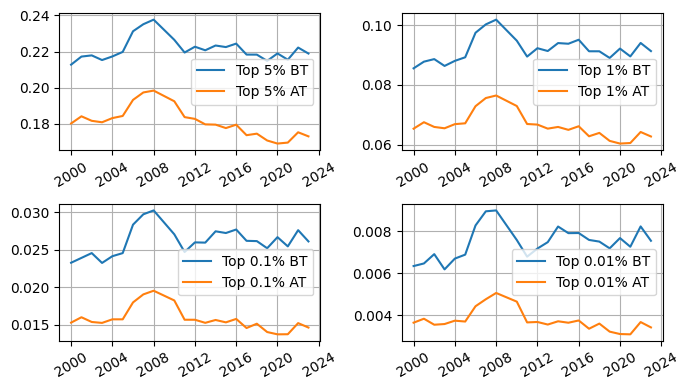

In [42]:
labels = ['Top 5%','Top 1%','Top 0.1%','Top 0.01%']
n = len(labels)

fig, axs = plt.subplots(2, 2,figsize=(7,4))

axs = axs.ravel()

for i in range(n):
    ax = axs[i]
    ax.tick_params(axis='x', labelrotation=30)
    ax.plot(years_dt,s_bt_xs[:,i],label = labels[i]+' BT')
    ax.plot(years_dt,s_at_xs[:,i],label = labels[i]+' AT')
    ax.grid()
    ax.legend()
        
fig.tight_layout()

# plt.savefig(direc_save+'income_top_shares1.png', bbox_inches='tight')

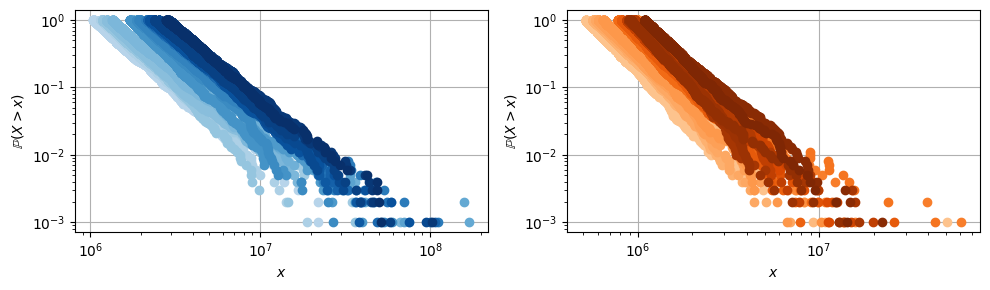

In [43]:
n = len(years)
N = 1000
top_N_y = np.arange(1/N,1+1/N,1/N)[::-1]

cmap = plt.get_cmap("Blues")
colors = [cmap(i) for i in np.linspace(0.3, 1, n)]

cmap1 = plt.get_cmap("Oranges")
colors1 = [cmap1(i) for i in np.linspace(0.3, 1, n)]

fig, axs = plt.subplots(1, 2,figsize=(10,3))

ax1, ax2 = axs[0], axs[1]

for i in range(n):
    ax1.loglog(dict_gen_pop_bt[years[i]][-N:],top_N_y,'o',color = colors[i])
    ax2.loglog(dict_gen_pop_at[years[i]][-N:],top_N_y,'o',color = colors1[i])

ax1.grid()
ax2.grid()

ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$\mathbb{P}(X>x)$')

ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$\mathbb{P}(X>x)$')

fig.tight_layout()

# Taxation

In [44]:
i = -1
s = dict_gen_pop_bt[years[i]]
pc = dict_bt[years[i]]

In [45]:
print(y[0],y[84],y[94])

0.99 0.15000000000000002 0.05


In [46]:
b = [pc[0],pc[84],pc[94]]
print(b)
t = [0,0.2,0.4,0.45]

t1 = [0,0.21,0.4,0.45]
t2 = [0,0.2,0.4,0.7]
t3 = [0,0.2,0.5,0.6]

[12800.0, 53700.0, 90500.0]


In [47]:
s_at = inc_after_band_tax(s,b,t)

In [48]:
s_at1 = inc_after_band_tax(s,b,t1)
s_at2 = inc_after_band_tax(s,b,t2)
s_at3 = inc_after_band_tax(s,b,t3)

In [49]:
print(income_tax_shares(s,0,b))
print(income_tax_shares(s,s_at,b))
print('')
print(income_tax_shares(s,s_at1,b))
print(income_tax_shares(s,s_at2,b))
print(income_tax_shares(s,s_at3,b))

[0.0025713166268506228, 0.5907046720300716, 0.18340918319639335, 0.22331482814668355]
[0.0, 0.35629564964126614, 0.21019526515448536, 0.4335090852042467]

[0.0, 0.364199805266021, 0.21075955008894123, 0.42504064464502883]
[0.0, 0.31131676079981413, 0.18366014053002763, 0.5050230986701525]
[0.0, 0.31374780035026306, 0.20363180878426, 0.48262039086548125]


In [50]:
print(prop_tax(s_at,s))
print('')
print(prop_tax(s_at1,s))
print(prop_tax(s_at2,s))
print(prop_tax(s_at3,s))

0.17676115656306668

0.18157119171474279
0.20229951945785818
0.20073202437967808


In [51]:
%%time
prop_tax_v1 = []
prop_tax_v2 = []
prop_tax_v3 = []

ti1 = np.arange(0.2,0.35,0.01)
ti2 = np.arange(0.45,0.95,0.01)
ti3 = np.arange(0.4,0.8,0.01)

for i in ti1:
    print(i)
    t = np.asarray([0,i,0.4,0.45],float)
    prop_tax_v1.append(prop_tax2(s,b,t)) # prop_tax2 gives same output as prop_tax1

print('')

for i in ti2:
    print(i)
    t = np.asarray([0,0.2,0.4,i],float)
    prop_tax_v2.append(prop_tax2(s,b,t))

print('')

for i in ti3:
    print(i)
    t = np.asarray([0,0.2,i,i+0.1],float)
    prop_tax_v3.append(prop_tax2(s,b,t))

0.2
0.21000000000000002
0.22000000000000003
0.23000000000000004
0.24000000000000005
0.25000000000000006
0.26000000000000006
0.2700000000000001
0.2800000000000001
0.2900000000000001
0.3000000000000001
0.3100000000000001
0.3200000000000001
0.3300000000000001
0.34000000000000014

0.45
0.46
0.47000000000000003
0.48000000000000004
0.49000000000000005
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.5700000000000001
0.5800000000000001
0.5900000000000001
0.6000000000000001
0.6100000000000001
0.6200000000000001
0.6300000000000001
0.6400000000000001
0.6500000000000001
0.6600000000000001
0.6700000000000002
0.6800000000000002
0.6900000000000002
0.7000000000000002
0.7100000000000002
0.7200000000000002
0.7300000000000002
0.7400000000000002
0.7500000000000002
0.7600000000000002
0.7700000000000002
0.7800000000000002
0.7900000000000003
0.8000000000000003
0.8100000000000003
0.8200000000000003
0.8300000000000003
0.8400000000000003
0.8500000000000003
0.8600000000000003
0.8700000000000003
0.8800000000000003
0.89000000

In [52]:
share = 0.2
ind1 = find_closest_index(prop_tax_v1, share)
ind2 = find_closest_index(prop_tax_v2, share)
ind3 = find_closest_index(prop_tax_v3, share)

print(ti1[ind1],ti2[ind2],ti3[ind3])

0.25000000000000006 0.6800000000000002 0.5000000000000001


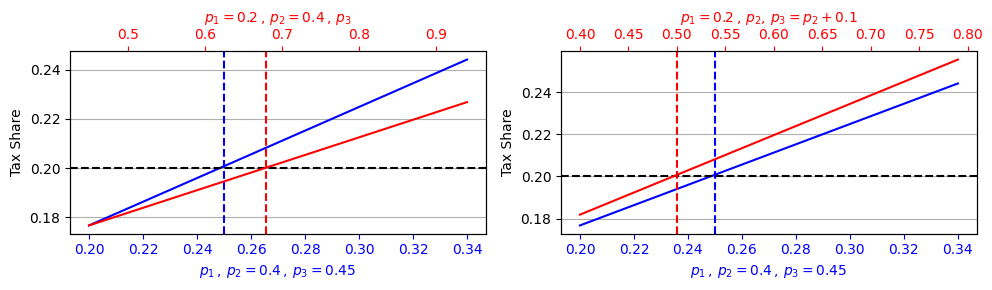

In [53]:
fig, axs = plt.subplots(1, 2,figsize=(10,3))

ax1, ax2 = axs[0], axs[1]

ax1.plot(ti1,prop_tax_v1, color='blue')
ax1.set_xlabel(r'$p_1\,,\, p_2 = 0.4 \,,\,p_3 = 0.45$',color = 'blue')
ax1.set_ylabel('Tax Share')
ax1.grid(True, axis='y')
ax1.axhline(0.2,color='black',linestyle='--')
ax1.axvline(ti1[ind1],color='blue',linestyle='--')
ax1.tick_params(axis='x', colors='blue')

ax11 = ax1.twiny()
ax11.plot(ti2,prop_tax_v2, color='red')
ax11.set_xlabel(r'$p_1 = 0.2\,,\,p_2 = 0.4\,,\,p_3$',color = 'red')
ax11.tick_params(axis='x', colors='red')
ax11.axvline(ti2[ind2],color='red',linestyle='--')

ax2.plot(ti1,prop_tax_v1, color='blue')
ax2.set_xlabel(r'$p_1\,,\, p_2 = 0.4 \,,\,p_3 = 0.45$',color = 'blue')
ax2.set_ylabel('Tax Share')
ax2.grid(True, axis='y')
ax2.axhline(0.2,color='black',linestyle='--')
ax2.axvline(ti1[ind1],color='blue',linestyle='--')
ax2.tick_params(axis='x', colors='blue')

ax21 = ax2.twiny()
ax21.plot(ti3,prop_tax_v3, color='red')
ax21.set_xlabel(r'$p_1 = 0.2\,,\,p_2, \, p_3 = p_2+0.1$',color = 'red')
ax21.tick_params(axis='x', colors='red')
ax21.axvline(ti3[ind3],color='red',linestyle='--')

fig.tight_layout()

# plt.savefig(direc_save+'tax_comparisons.png', bbox_inches='tight')